In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('house_price_regression_dataset.csv')
print("Shape:", df.shape)
df.head()

# Keterangan Info Tabel:
# - Square Footage: Luas rumah dalam kaki persegi
# - Number of Bedrooms: Jumlah kamar tidur
# - Number of Bathrooms: Jumlah kamar mandi
# - Year Built: Tahun dibangunnya rumah
# - Lot Size: Ukuran lahan dalam acre
# - Garage Size: Ukuran garasi dalam mobil
# - Neighborhood Quality: Kualitas lingkungan (skala 1-10)
# - House Price: Harga rumah dalam dolar

Shape: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [9]:
# cek info, missing values, dan duplikat
print("INFO DATASET")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLIKAT")
print("Jumlah duplikat:", df.duplicated().sum())

print("\nSTATISTIK DESKRIPTIF")
df.describe()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB
None

MISSING VALUES
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

DUPLIKAT
Jumlah duplikat: 0

STATISTIK DESKRIPTIF


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


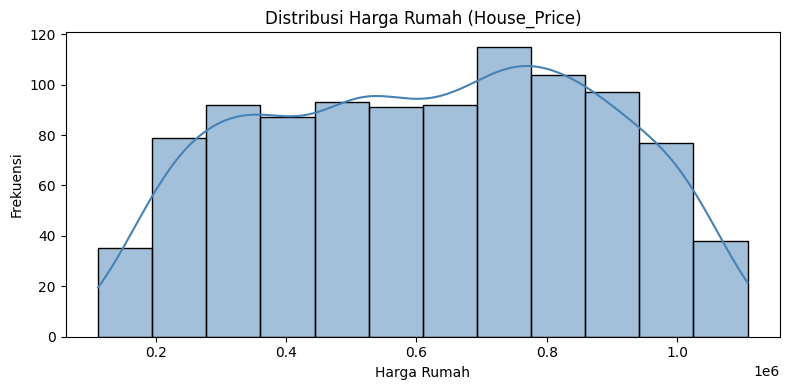

In [10]:
# distribusi harga rumah
plt.figure(figsize=(8, 4))
sns.histplot(df['House_Price'], kde=True, color='steelblue')
plt.title('Distribusi Harga Rumah (House_Price)')
plt.xlabel('Harga Rumah')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

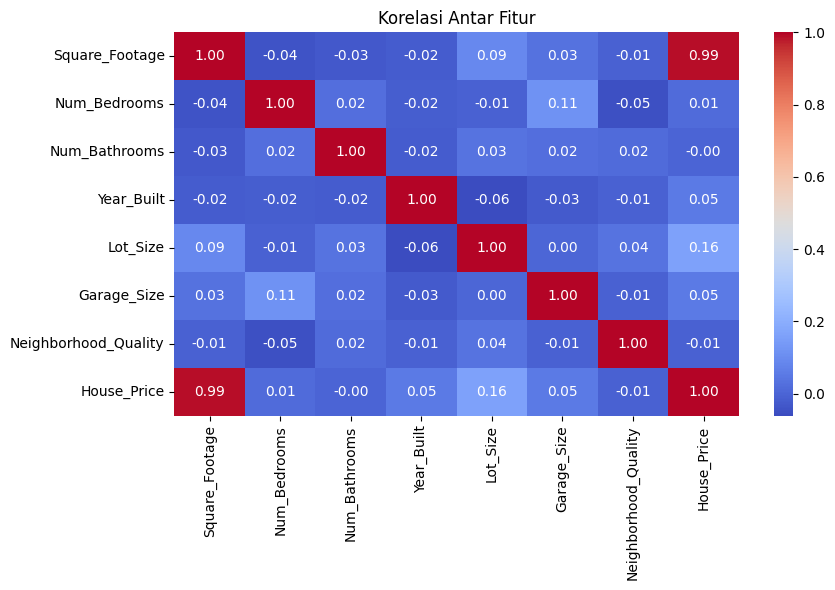

In [11]:
# korelasi antar fitur
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

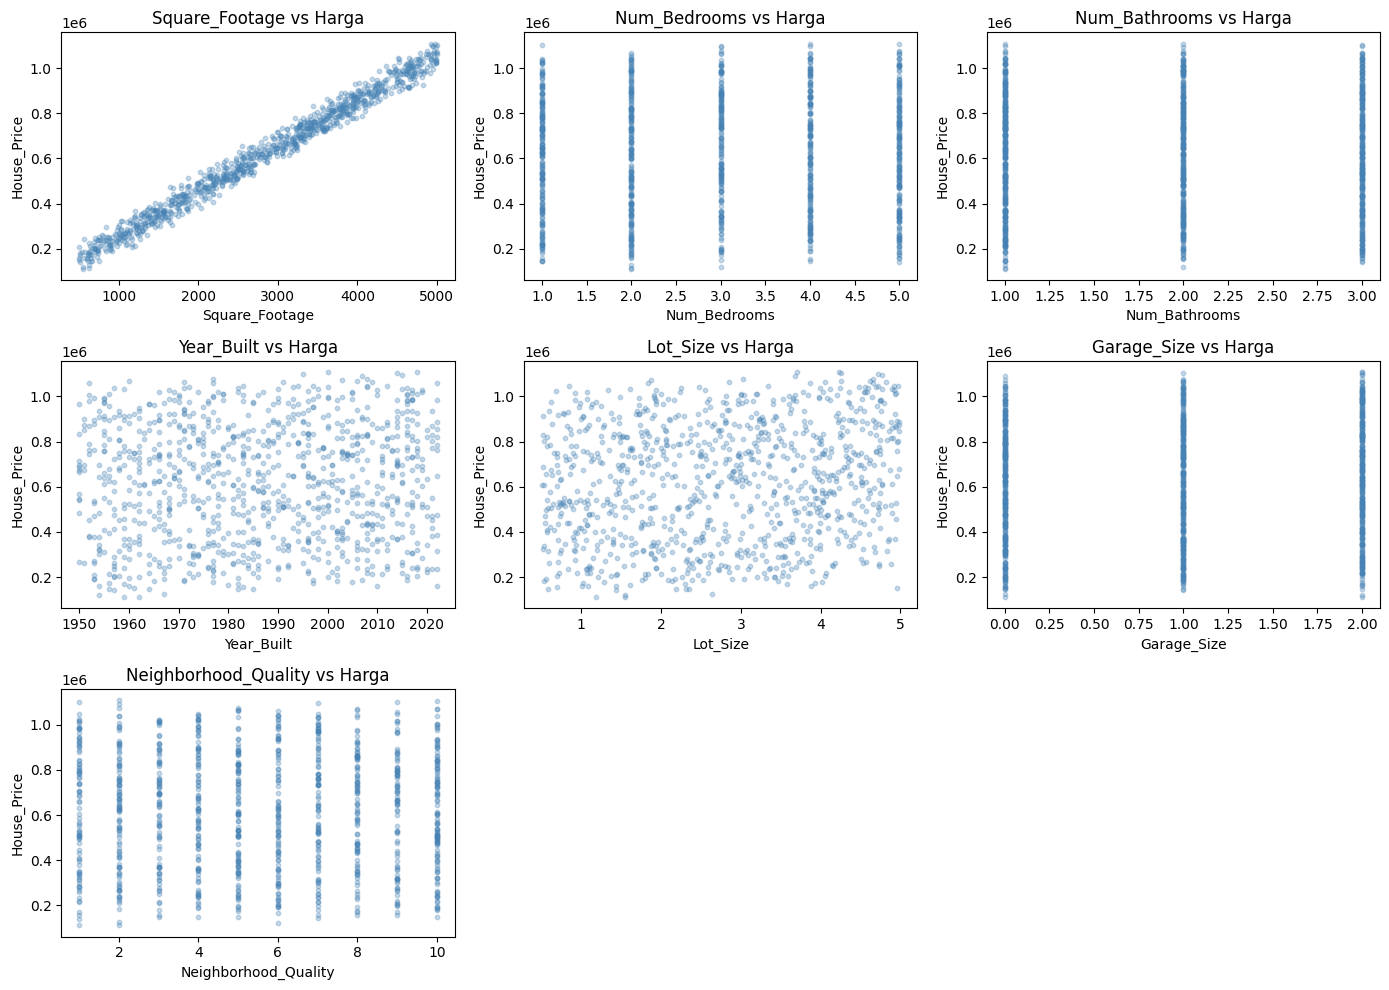

In [12]:
# scatter plot tiap fitur vs harga
fitur = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms',
         'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']

plt.figure(figsize=(14, 10))
for i, col in enumerate(fitur):
    plt.subplot(3, 3, i+1)
    plt.scatter(df[col], df['House_Price'], alpha=0.3, color='steelblue', s=10)
    plt.xlabel(col)
    plt.ylabel('House_Price')
    plt.title(f'{col} vs Harga')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

# Pisah fitur sama target
X = df.drop(columns=['House_Price'])
y = df['House_Price']

# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Data siap dipakai!")
print(f"Train : {X_train_scaled.shape}")
print(f"Test  : {X_test_scaled.shape}")

Data siap dipakai!
Train : (800, 7)
Test  : (200, 7)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model berhasil dilatih!")
print(f"\nIntercept : {model.intercept_:.4f}")
print("\nKoefisien tiap fitur:")
for fitur, koef in zip(X.columns, model.coef_):
    print(f"  {fitur:30s} → {koef:.4f}")

Model berhasil dilatih!

Intercept : 618576.0544

Koefisien tiap fitur:
  Square_Footage                 → 249787.9148
  Num_Bedrooms                   → 14524.7344
  Num_Bathrooms                  → 6695.9068
  Year_Built                     → 20662.1216
  Lot_Size                       → 19088.1110
  Garage_Size                    → 4219.4494
  Neighborhood_Quality           → 335.2475


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("HASIL EVALUASI MODEL")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

HASIL EVALUASI MODEL
MAE  : 8174.5836
MSE  : 101434798.5056
RMSE : 10071.4844
R²   : 0.9984


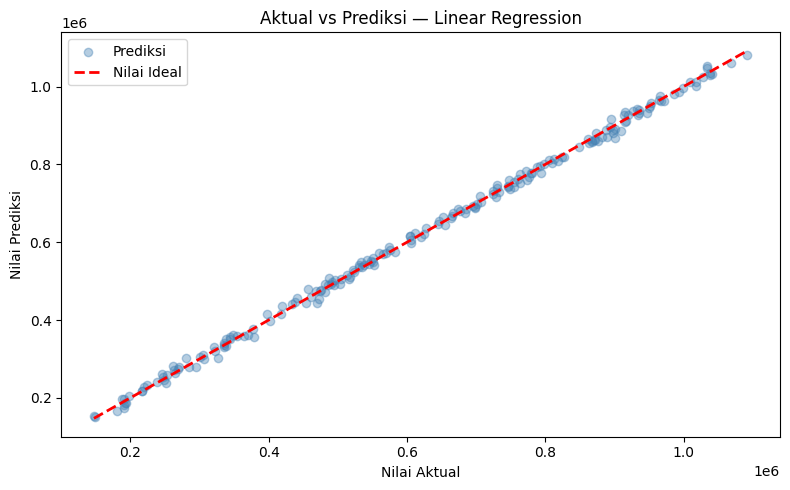

In [ ]:
# plot prediksi vs aktual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', label='Prediksi')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Nilai Ideal')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Aktual vs Prediksi — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# simpan model dan scaler
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("model.pkl: tersimpan!")
print("scaler.pkl: tersimpan!")

model.pkl: tersimpan!
scaler.pkl: tersimpan!
